<div dir="rtl" style="text-align:right; font-family:'Segoe UI', 'Arial Hebrew', Arial, sans-serif; border-right:6px solid #f59f00; padding:14px 22px 14px 18px; margin-bottom:18px;">

<h1 style="margin:0 0 6px; color:#212529;">NetSec Dashboard &mdash; דיון על DBSCAN</h1>

<div style="font-size:14.5px; color:#495057;">קלאסטרינג לא-מפוקח לזיהוי אנומליות בתעבורת רשת. שאלות פתוחות על DBSCAN בהקשר הפרויקט, ועל הצעת מעבר ל-HDBSCAN.</div>

</div>


<div dir="rtl" style="text-align:right; font-family:'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:14.5px; color:#212529;">

## הקשר הפרויקט

<b>NetSec Dashboard</b> הוא כלי פורנזי לניתוח קבצי <code>.pcapng</code> מ-Wireshark (או הקלטה חיה דרך <code>tshark</code>), בנוי על <b>Dash + scikit-learn + PyTorch</b>.

הצינור המלא:

<ol style="padding-right:22px; margin:6px 0;">
<li>קריאת ה-PCAP &mdash; כל הפקטות, ה-IP-ים וה-flows.</li>
<li>חילוץ <b>7 פיצ'רים פר-IP</b>: <code>mean_len, std_len, count, burst_score, unique_dsts, syn_count, rst_count</code>.</li>
<li>נירמול עם <code>StandardScaler</code> &mdash; ממוצע 0, סטיית תקן 1. קריטי כי הסקאלות שונות מאוד (count בעשרות-אלפים מול std_len קטן).</li>
<li>הרצת <b>שלושה מודלי ML במקביל</b> + שכבות חוקים דטרמיניסטיים.</li>
<li>בניית <b>Model Agreement Matrix</b> &mdash; מציגה איפה המודלים מסכימים.</li>
<li>השוואה צד-בצד של שני סשנים (<b>S1</b>, <b>S2</b>).</li>
</ol>

הדיון כאן מתמקד <b>במודל DBSCAN בלבד</b>. שני המודלים האחרים (<b>Isolation Forest</b> ו-<b>LSTM</b>) חלק מהצינור אך אינם מוקד הדיון.

</div>


<div dir="rtl" style="background:#fff8e1; border-right:5px solid #f59f00; border-radius:10px; padding:18px 22px; margin:8px 0 14px; font-family: 'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:15px; color:#222;">

<div style="font-size:18px; font-weight:700; color:#b8540a; margin-bottom:10px;">שאלה #1 &mdash; האם DBSCAN המודל המתאים לנתונים האלה?</div>

הקוד בוחר <code>eps</code> אוטומטית באמצעות שיטת <b>k-distance elbow</b>. בריצה על שני קבצי לכידה (S1, S2) של אותה רשת התקבלו ערכים שונים מאוד &mdash; <code>0.78</code> ב-S1 ו-<code>4.86</code> ב-S2 (מתועד ב-<code>docs/MODEL_DIAGNOSTICS.md</code>). בשני המקרים DBSCAN מקבץ את כל ה-IP-ים ל-<b>אשכול יחיד</b> + מספר מועט של נקודות noise, ו-Silhouette אינו מוגדר.<br><br>השאלה: בנתונים מסוג זה &mdash; האם DBSCAN הוא המודל המתאים, או שהפיצ'רים אינם מספיקים להפרדה והכיוון צריך להיות <b>HDBSCAN</b>?

<img alt="S1 captured cell output: feature matrix, IsolationForest sweep, DBSCAN summary (eps=0.78, clusters=1, noise=6, silhouette=n/a)" style="display:block; max-width:720px; width:100%; margin:12px 0 4px; border:1px solid #e2c878; border-radius:6px;" src="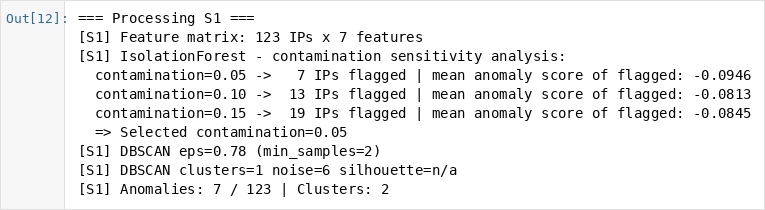" />
</div>


In [ ]:
print(f"[{S['label']}] DBSCAN eps={eps_auto:.2f} (min_samples=2)")
dbscan = DBSCAN(eps=eps_auto, min_samples=2)
ip_agg["cluster"] = dbscan.fit_predict(X)

from sklearn.metrics import silhouette_score
_labels   = ip_agg["cluster"].values
_nonnoise = _labels != -1
_n_clusters = int(len(set(_labels[_nonnoise])))
_n_noise    = int((_labels == -1).sum())
try:
    if _nonnoise.sum() >= 2 and _n_clusters >= 2:
        _sil = float(silhouette_score(X[_nonnoise], _labels[_nonnoise]))
    else:
        _sil = None
except Exception:
    _sil = None

print(f"[{S['label']}] DBSCAN clusters={_n_clusters} noise={_n_noise} "
      f"silhouette={('n/a' if _sil is None else round(_sil,3))}")


<div dir="rtl" style="background:#fff8e1; border-right:5px solid #f59f00; border-radius:10px; padding:18px 22px; margin:8px 0 14px; font-family: 'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:15px; color:#222;">

<div style="font-size:18px; font-weight:700; color:#b8540a; margin-bottom:10px;">שאלה #2 &mdash; <code>eps</code> דינמי לכל סשן &mdash; האם זה לגיטימי?</div>

הקוד מחשב <code>k-distance</code> עם <code>k=2</code> בנפרד לכל סשן, מאתר את ה<b>מרפק</b> (נגזרת שנייה מינימלית), ועושה <code>round</code> ל-2 ספרות. כאשר יש פחות מ-4 IP-ים &mdash; <code>fallback</code> ל-1.3.<br><br>בשתי הריצות, על אותו צינור ואותה רשת, <code>eps</code> התקבל <b>0.78</b> ב-S1 ו-<b>4.86</b> ב-S2 &mdash; יחס של פי 6.2. מצד אחד זה מתאים את ההגדרה לצפיפות הנתונים של כל סשן בנפרד &mdash; מצד שני, סיווגי ה-clusters בין S1 ל-S2 אינם השוואתיים, כי הסף שונה בכל אחד מהם.<br><br>השאלה: מהי הפרקטיקה המקובלת &mdash; <code>eps</code> אחיד שמחושב על הסשן הראשון בלבד? ממוצע על כמה סשנים? שמירה על <code>eps</code> נפרד תוך ציון מפורש בדוח שהסיווגים אינם השוואתיים?

<img alt="S1 DBSCAN summary line - captured from notebook cell output" style="display:block; max-width:720px; width:100%; margin:12px 0 4px; border:1px solid #e2c878; border-radius:6px;" src="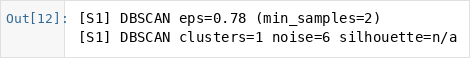" />

<img alt="S2 DBSCAN line from MODEL_DIAGNOSTICS.md - eps=4.86 on the same network" style="display:block; max-width:720px; width:100%; margin:12px 0 4px; border:1px solid #e2c878; border-radius:6px;" src="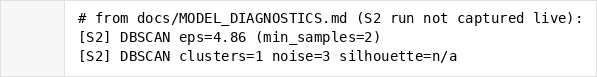" />
</div>


In [ ]:
k = 2
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dist = np.sort(distances[:, k-1])[::-1]
if len(k_dist) >= 4:
    d1 = np.diff(k_dist)
    d2 = np.diff(d1)
    elbow_idx = int(np.argmin(d2)) + 1
    eps_auto  = float(round(k_dist[elbow_idx], 2))
else:
    eps_auto = 1.3

print(f"[{S['label']}] DBSCAN eps={eps_auto:.2f} (min_samples=2)")
dbscan = DBSCAN(eps=eps_auto, min_samples=2)
ip_agg["cluster"] = dbscan.fit_predict(X)


<div dir="rtl" style="background:#fff8e1; border-right:5px solid #f59f00; border-radius:10px; padding:18px 22px; margin:8px 0 14px; font-family: 'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:15px; color:#222;">

<div style="font-size:18px; font-weight:700; color:#b8540a; margin-bottom:10px;">שאלה #3 &mdash; ערך ה-<code>fallback</code> של 1.3</div>

במקרה של סשן זעיר (פחות מ-4 IP-ים), הקוד עובר לערך קבוע <code>eps=1.3</code>. במצב כזה התוצאה למעשה היא קיבוץ של כל הנקודות לאשכול אחד.<br><br>השאלה: האם יש ערך התחלתי מבוסס יותר שכדאי לבחור עבור התחום, למשל בהתבסס על מרחק נורמלי אופייני אחרי <code>StandardScaler</code>?
</div>


In [ ]:
k = 2
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dist = np.sort(distances[:, k-1])[::-1]
if len(k_dist) >= 4:
    d1 = np.diff(k_dist)
    d2 = np.diff(d1)
    elbow_idx = int(np.argmin(d2)) + 1
    eps_auto  = float(round(k_dist[elbow_idx], 2))
else:
    eps_auto = 1.3    # <-- the hard-coded fallback in question


<div dir="rtl" style="background:#fff8e1; border-right:5px solid #f59f00; border-radius:10px; padding:18px 22px; margin:8px 0 14px; font-family: 'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:15px; color:#222;">

<div style="font-size:18px; font-weight:700; color:#b8540a; margin-bottom:10px;">שאלה #4 &mdash; <code>Silhouette = n/a</code> &mdash; כיצד למדוד איכות?</div>

בכרטיס <code>Model Diagnostics</code> של הדשבורד מתקבל <code>Silhouette = n/a</code>. הקוד מחזיר <code>None</code> כאשר יש פחות מ-2 clusters &mdash; וזה נכון מתמטית, כי Silhouette אינו מוגדר עבור cluster יחיד.<br><br>כאשר DBSCAN מתכנס לאשכול יחיד + noise, Silhouette אינו ישים. עדיין דרושה דרך לכמת את <b>איכות ההפרדה</b> בין האשכול לנקודות ה-noise.<br><br>השאלה: כיצד ניתן לכמת את איכות ההפרדה כאשר Silhouette אינו ישים? ובאופן עקרוני &mdash; האם cluster יחיד עם 6 <code>noise points</code> הוא ממצא משמעותי, או שזה כישלון של המודל?

<img alt="S1 DBSCAN result line: clusters=1, noise=6, silhouette=n/a" style="display:block; max-width:720px; width:100%; margin:12px 0 4px; border:1px solid #e2c878; border-radius:6px;" src="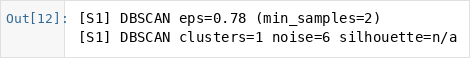" />
</div>


In [ ]:
from sklearn.metrics import silhouette_score
_labels   = ip_agg["cluster"].values
_nonnoise = _labels != -1
_n_clusters = int(len(set(_labels[_nonnoise])))
_n_noise    = int((_labels == -1).sum())
try:
    if _nonnoise.sum() >= 2 and _n_clusters >= 2:
        _sil = float(silhouette_score(X[_nonnoise], _labels[_nonnoise]))
    else:
        _sil = None     # the branch hit in both sessions
except Exception:
    _sil = None

S["_silhouette"]  = _sil
S["_n_clusters"]  = _n_clusters
S["_n_noise"]     = _n_noise


<div dir="rtl" style="background:#fff8e1; border-right:5px solid #f59f00; border-radius:10px; padding:18px 22px; margin:8px 0 14px; font-family: 'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:15px; color:#222;">

<div style="font-size:18px; font-weight:700; color:#b8540a; margin-bottom:10px;">שאלה #5 &mdash; הצעת הוספה &mdash; HDBSCAN + Hopkins statistic</div>

שתי הוספות מוצעות לפרויקט:<br><br>1. <b>Hopkins statistic</b> כצעד מקדים &mdash; בודק האם קיים מבנה אשכולי בנתונים לפני הרצת קלאסטרינג.<br>2. <b>HDBSCAN</b> כקלאסטרינג ראשי במקום DBSCAN, עם <b>fallback ל-DBSCAN</b> במקרה ש-HDBSCAN אינו זמין או אינו מצליח להחזיר clusters.<br><br>הרציונל: HDBSCAN אינו דורש <code>eps</code> ומטפל ב<b>צפיפויות משתנות</b>, שזה מאפיין מובהק של תעבורת רשת. הגישה הזאת עשויה לפתור את שתי הבעיות מהשאלות הקודמות &mdash; <code>eps</code> דינמי בין סשנים, ואשכול יחיד.<br><br>השאלה: האם הגישה הזאת מקובלת? איזה ערך סף של Hopkins נחשב הוכחה לקיום מבנה אשכולי בנתונים?<br><br><i style="color:#9d4f00;">הערה: קטע הקוד למטה הוא הצעה לא ממומשת &mdash; הוא לא קיים בפרויקט כיום.</i>
</div>


In [ ]:
# === PROPOSED, NOT YET IN THE PROJECT ===
def hopkins_statistic(X, m=None, random_state=42):
    """H ~ 0.5 = random; H > 0.7 = cluster tendency."""
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    if m is None: m = max(5, int(0.1 * n))
    idx     = rng.choice(n, size=m, replace=False)
    sample  = X[idx]
    mins, maxs = X.min(axis=0), X.max(axis=0)
    synth   = rng.uniform(mins, maxs, size=(m, d))
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    w = nbrs.kneighbors(sample, n_neighbors=2)[0][:, 1]
    u = nbrs.kneighbors(synth,  n_neighbors=1)[0][:, 0]
    return float(u.sum() / (u.sum() + w.sum()))

H = hopkins_statistic(X)         # would be reported alongside silhouette

# Primary: HDBSCAN if installed; otherwise DBSCAN as fallback
if HDBSCAN_AVAILABLE and X.shape[0] >= 5:
    import hdbscan
    hdb = hdbscan.HDBSCAN(min_cluster_size=max(3, int(0.03 * X.shape[0])),
                          min_samples=2)
    labels = hdb.fit_predict(X)
    n_clusters_hdb = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters_hdb >= 1:
        ip_agg["cluster"]      = labels
        ip_agg["cluster_prob"] = hdb.probabilities_
    else:
        ip_agg["cluster"] = dbscan_fallback(X)
else:
    ip_agg["cluster"] = dbscan_fallback(X)


<div dir="rtl" style="background:#fff8e1; border-right:5px solid #f59f00; border-radius:10px; padding:18px 22px; margin:8px 0 14px; font-family: 'Segoe UI', 'Arial Hebrew', Arial, sans-serif; line-height:1.75; font-size:15px; color:#222;">

<div style="font-size:18px; font-weight:700; color:#b8540a; margin-bottom:10px;">שאלה #6 &mdash; הערכה בהיעדר תוויות אמת</div>

הפרויקט לא-מפוקח &mdash; אין <code>ground truth</code>, ולכן לא ניתן למדוד <code>precision/recall</code>. ההערכה מסתמכת על מדדים פנימיים: <b>Silhouette</b> (כאשר מוגדר), יחס clusters-to-noise, וההסכמה בין המודלים השונים שבצינור.<br><br>השאלה: כדי לחזק את ההערכה &mdash; האם <b>הזרקת התקפות סינתטיות ידועות</b> (<code>port scan</code>, <code>DNS tunneling</code>) לתוך ה-PCAP, במטרה ליצור <code>ground truth</code> נקודתי, היא פרקטיקה מקובלת בתחום?
</div>


In [ ]:
# Every metric stored is INTERNAL - computed from the data itself,
# without any external labels.
S["_chosen_contamination"] = best_cont   # picked by sensitivity sweep
S["_eps_auto"]    = eps_auto             # k-distance elbow per session
S["_min_samples"] = 2
S["_silhouette"]  = _sil                 # often n/a (only 1 cluster)
S["_n_clusters"]  = _n_clusters
S["_n_noise"]     = _n_noise

print(f"[{S['label']}] DBSCAN clusters={_n_clusters} noise={_n_noise} "
      f"silhouette={('n/a' if _sil is None else round(_sil,3))}")
print(f"[{S['label']}] Anomalies: {ip_agg['anomaly'].sum()} / {len(ip_agg)} | "
      f"Clusters: {ip_agg['cluster'].nunique()}")
